# Previsão de Churn (Cancelamento) de Alunos — CEUB / PIM

**Objetivo:** construir um modelo de *alerta antecipado* (early-warning) que estime a
probabilidade de um aluno **cancelar o plano** a partir do seu **histórico de parcelas**.

### Como o problema é modelado
- **Unidade de análise:** o **aluno** (uma linha por matrícula).
- **Alvo (`churn`):** `1` se o aluno possui ao menos uma parcela com situação **Cancelado**;
  `0` caso contrário.
- **Anti-vazamento (data leakage):** para cada aluno que cancelou, os atributos são
  calculados **apenas com as parcelas anteriores ao cancelamento** (janela de observação).
  Nenhuma informação da parcela cancelada entra como atributo — caso contrário o modelo
  apenas "decoraria" o rótulo.

### Etapas do notebook
1. Carga e limpeza dos dados
2. Análise Exploratória (EDA) — estatísticas descritivas e gráficos
3. Engenharia de atributos em nível de aluno (janela pré-cancelamento)
4. EDA orientada ao alvo (relação dos atributos com o churn)
5. Modelagem e comparação de algoritmos
6. Métricas, estatísticas e gráficos de desempenho
7. Interpretabilidade e conclusões

> **Escalabilidade:** o notebook é parametrizado. Para usar a base completa (~70k linhas),
> basta alterar `DATA_PATH` na célula de configuração; o restante roda sem mudanças.

## 1. Configuração e bibliotecas

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

try:
    from xgboost import XGBClassifier
    TEM_XGB = True
except Exception:
    TEM_XGB = False

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13

# ---- Parâmetros do projeto -------------------------------------------------
DATA_PATH    = 'ParcelaEmAberto-564fb28d84ebc24b0a5a3899b1b3355b-1782162365081.xls'  # base completa (~70k linhas); .xls/.xlsx
RANDOM_STATE = 42
TEST_SIZE    = 0.25
TOP_PLANOS   = 8     # nº de planos mantidos individualmente (demais viram 'Outros')
TOP_FORMAS   = 6     # idem para forma de pagamento

print('Bibliotecas carregadas. XGBoost disponivel:', TEM_XGB)

Bibliotecas carregadas. XGBoost disponivel: True


## 2. Carga dos dados

O arquivo exportado possui uma **linha de título** antes do cabeçalho real. A função abaixo
detecta automaticamente a linha de cabeçalho (a que contém *Matrícula*), de modo a funcionar
tanto na amostra atual quanto na base completa.

In [2]:
def _engine_excel(caminho):
    """Escolhe o engine certo mesmo quando a extensao engana (ex.: um .xlsx exportado como .xls)."""
    with open(caminho, 'rb') as fh:
        assinatura = fh.read(8)
    if assinatura[:2] == b'PK':                # ZIP  => Office Open XML (.xlsx) -> openpyxl
        return 'openpyxl'
    if assinatura[:4] == b'\xd0\xcf\x11\xe0':  # OLE2 => Excel 97-2003 (.xls real) -> xlrd
        return 'xlrd'
    return None                                # formato desconhecido: deixa o pandas inferir

def carregar_dados(caminho):
    eng = _engine_excel(caminho)
    previa = pd.read_excel(caminho, header=None, nrows=5, engine=eng)
    linha_cab = 0
    for i in range(len(previa)):
        if previa.iloc[i].astype(str).str.contains('Matr', case=False, na=False).any():
            linha_cab = i
            break
    df = pd.read_excel(caminho, header=linha_cab, engine=eng)
    df.columns = [str(c).strip() for c in df.columns]
    return df

df_bruto = carregar_dados(DATA_PATH)
print('Dimensoes (linhas, colunas):', df_bruto.shape)
df_bruto.head()

Dimensoes (linhas, colunas): (71321, 20)


,Unnamed: 0,Empresa,Matrícula,Nome,Telefones,Nr.Contrato,Desc.Parcela,Cod.Parcela,Situação,Valor,Dt.Cancelamento,Recorrência,Dt.Faturamento,Dt.Vencimento,Dt.Pagamento,Forma,Plano,Convênios,Modalidades,Turma
0,NaN,ACADEMIA EQUILIBRIO E MOVIMENTO,014858,ISABELA MARIA DE CARVALHO LOPES,(61)998636117,18956,PARCELA 4,92714,Cancelado,"R$ 99,90",22/06/22 00:00,Sim,22/06/22 00:00,20/09/22 00:00,NaN,NaN,RECORRENCIA SETEMBRO/22,NaN,"ABDOMINAL,BIKE INDOOR,ERGOMETRIA,FITDANCE,FITN...",NaN
1,NaN,ACADEMIA EQUILIBRIO E MOVIMENTO,014858,ISABELA MARIA DE CARVALHO LOPES,(61)998636117,18956,PARCELA 5,92715,Cancelado,"R$ 99,90",22/06/22 00:00,Sim,22/06/22 00:00,20/10/22 00:00,NaN,NaN,RECORRENCIA SETEMBRO/22,NaN,"ABDOMINAL,BIKE INDOOR,ERGOMETRIA,FITDANCE,FITN...",NaN
2,NaN,ACADEMIA EQUILIBRIO E MOVIMENTO,014858,ISABELA MARIA DE CARVALHO LOPES,(61)998636117,18956,PARCELA 6,92716,Cancelado,"R$ 99,90",22/06/22 00:00,Sim,22/06/22 00:00,20/11/22 00:00,NaN,NaN,RECORRENCIA SETEMBRO/22,NaN,"ABDOMINAL,BIKE INDOOR,ERGOMETRIA,FITDANCE,FITN...",NaN
3,NaN,ACADEMIA EQUILIBRIO E MOVIMENTO,014858,ISABELA MARIA DE CARVALHO LOPES,(61)998636117,18956,PARCELA 7,92717,Cancelado,"R$ 99,90",22/06/22 00:00,Sim,22/06/22 00:00,20/12/22 00:00,NaN,NaN,RECORRENCIA SETEMBRO/22,NaN,"ABDOMINAL,BIKE INDOOR,ERGOMETRIA,FITDANCE,FITN...",NaN
4,NaN,ACADEMIA EQUILIBRIO E MOVIMENTO,014858,ISABELA MARIA DE CARVALHO LOPES,(61)998636117,18956,PARCELA 8,92718,Cancelado,"R$ 99,90",22/06/22 00:00,Sim,22/06/22 00:00,20/01/23 00:00,NaN,NaN,RECORRENCIA SETEMBRO/22,NaN,"ABDOMINAL,BIKE INDOOR,ERGOMETRIA,FITDANCE,FITN...",NaN


## 3. Limpeza e padronização

- Renomeamos as colunas para nomes canônicos (sem acentos/pontuação).
- Tratamos o caractere `-` como valor ausente.
- Convertemos **valor** para número, **datas** para `datetime` e extraímos o **número da parcela**.
- Removemos duplicatas exatas.

In [3]:
MAPA_COLUNAS = {
    'Matricula': 'matricula', 'Matrícula': 'matricula', 'Nome': 'nome',
    'Telefone': 'telefone', 'Telefones': 'telefone',
    'Contrato': 'contrato', 'Nr.Contrato': 'contrato',
    'Parcela': 'parcela', 'Desc.Parcela': 'parcela', 'Cod.Parcela': 'cod_parcela',
    'Situacao': 'situacao', 'Situação': 'situacao',
    'Valor': 'valor', 'Dt.Cancelamento': 'dt_cancelamento',
    'Recorrencia': 'recorrencia', 'Recorrência': 'recorrencia',
    'Faturamento': 'faturamento', 'Dt.Faturamento': 'faturamento',
    'Vencimento': 'vencimento', 'Dt.Vencimento': 'vencimento',
    'Pagamento': 'pagamento', 'Dt.Pagamento': 'pagamento',
    'Forma Pgto.': 'forma_pgto', 'Forma': 'forma_pgto',
    'Modalidades': 'modalidades', 'Resp. Pgto.': 'resp_pgto',
    'Turma': 'turma', 'Plano': 'plano',
    'Empresa': 'empresa', 'Convênios': 'convenios', 'Convenios': 'convenios',
}

# Colunas canônicas que o restante do notebook utiliza. Bases diferentes do mesmo
# sistema trazem subconjuntos distintos (ex.: a exportação completa não tem "Resp. Pgto.");
# as ausentes são criadas vazias para que o pipeline rode sem alterações.
COLUNAS_ESPERADAS = ['matricula', 'nome', 'telefone', 'contrato', 'parcela', 'situacao',
                     'valor', 'recorrencia', 'faturamento', 'vencimento', 'pagamento',
                     'forma_pgto', 'modalidades', 'resp_pgto', 'turma', 'plano']

def _para_numero_brl(x):
    """Converte 'R$ 1.234,56' (e variações) em float; valores já numéricos passam direto."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    t = str(x).replace('R$', '').replace('\xa0', ' ').strip()
    if ',' in t:                       # formato brasileiro: '.' separa milhar, ',' é decimal
        t = t.replace('.', '').replace(',', '.')
    return pd.to_numeric(t, errors='coerce')

def limpar(df):
    df = df.rename(columns=MAPA_COLUNAS).copy()
    df = df.dropna(how='all')
    for col in COLUNAS_ESPERADAS:           # garante o schema mesmo se a base não traz a coluna
        if col not in df.columns:
            df[col] = np.nan
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'-': np.nan, 'nan': np.nan, 'NaT': np.nan, '': np.nan})
    df['matricula']   = df['matricula'].astype(str).str.strip()
    df['parcela_num'] = df['parcela'].astype(str).str.extract(r'(\d+)', expand=False).astype(float)
    df['valor']       = df['valor'].map(_para_numero_brl).round(2)
    for c in ['faturamento', 'vencimento', 'pagamento']:
        df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=True)
    df['situacao'] = df['situacao'].str.title()
    df = df.drop_duplicates().reset_index(drop=True)
    return df

df = limpar(df_bruto)
print('Apos limpeza (linhas, colunas):', df.shape)
df.info()

Apos limpeza (linhas, colunas): (71321, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71321 entries, 0 to 71320
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       0 non-null      float64       
 1   empresa          71321 non-null  object        
 2   matricula        71321 non-null  object        
 3   nome             71321 non-null  object        
 4   telefone         71258 non-null  object        
 5   contrato         71321 non-null  int64         
 6   parcela          71321 non-null  object        
 7   cod_parcela      71321 non-null  int64         
 8   situacao         71321 non-null  object        
 9   valor            71321 non-null  float64       
 10  dt_cancelamento  12471 non-null  object        
 11  recorrencia      71321 non-null  object        
 12  faturamento      71321 non-null  datetime64[ns]
 13  vencimento       71321 non-null  datetime64[ns]

### 3.1 Atributos derivados a nível de parcela

In [4]:
def grupo_modalidade(m):
    if pd.isna(m):
        return 'Desconhecida'
    t = str(m).lower()
    if 'natac' in t or 'nataç' in t:           return 'Natação'
    if 'hidro' in t:                            return 'Hidroginástica'
    if 'taekwondo' in t or 'jiu' in t:          return 'Lutas'
    if 'crosstraining' in t:                    return 'Crosstraining'
    if (',' in t) or ('muscula' in t) or ('fitness' in t) or ('bike' in t):
        return 'Academia/Fitness'
    return 'Outros'

def _conta_itens(s):
    if pd.isna(s):
        return 0
    return len([x for x in str(s).split(',') if x.strip()])

df['modalidade_grupo'] = df['modalidades'].apply(grupo_modalidade)
df['n_modalidades']    = df['modalidades'].apply(_conta_itens)
df['n_telefones']      = df['telefone'].apply(_conta_itens)

df['modalidade_grupo'].value_counts()

modalidade_grupo
Academia/Fitness    45190
Natação             14590
Desconhecida         5327
Hidroginástica       4996
Crosstraining         744
Lutas                 393
Outros                 81
Name: count, dtype: int64

## 4. Análise Exploratória (EDA)

### 4.1 Estatísticas descritivas e valores ausentes

In [5]:
print('Periodo de vencimentos:', df['vencimento'].min(), 'a', df['vencimento'].max())
print('Alunos unicos:', df['matricula'].nunique(), '| Contratos:', df['contrato'].nunique(),
      '| Parcelas:', len(df))
display(df.describe(include='all').T)

ausentes = df.isna().sum().sort_values(ascending=False)
ausentes = ausentes[ausentes > 0].to_frame('qtd_ausentes')
ausentes['pct'] = (ausentes['qtd_ausentes'] / len(df) * 100).round(1)
print('\nValores ausentes por coluna:')
display(ausentes)

Periodo de vencimentos: 2022-06-22 00:00:00 a 2026-06-22 00:00:00
Alunos unicos: 4364 | Contratos: 8489 | Parcelas: 71321


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Unnamed: 0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empresa,71321,1,ACADEMIA EQUILIBRIO E MOVIMENTO,71321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
matricula,71321,4364,009603,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nome,71321,4363,ONILO ALVES DOS SANTOS,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telefone,71258,4003,"(61) 98304-8166,(61) 98108-6194,(61) 3483-0373",189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contrato,71321.0,NaN,NaN,NaN,21395.773068,0.0,20498.0,22684.0,24937.0,28297.0,6525.486933
parcela,71321,283,PARCELA 1,8161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cod_parcela,71321.0,NaN,NaN,NaN,133629.191066,92714.0,113102.0,133095.0,153388.0,183756.0,24009.415633
situacao,71321,3,Pago,58594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
valor,71321.0,NaN,NaN,NaN,146.975086,0.0,109.9,144.9,169.9,4800.0,108.324848



Valores ausentes por coluna:


,qtd_ausentes,pct
Unnamed: 0,71321,100.0
resp_pgto,71321,100.0
dt_cancelamento,58850,82.5
turma,50571,70.9
convenios,38180,53.5
pagamento,13564,19.0
forma_pgto,13512,18.9
parcela_num,6906,9.7
modalidades,5327,7.5
plano,5327,7.5


### 4.2 Situação das parcelas

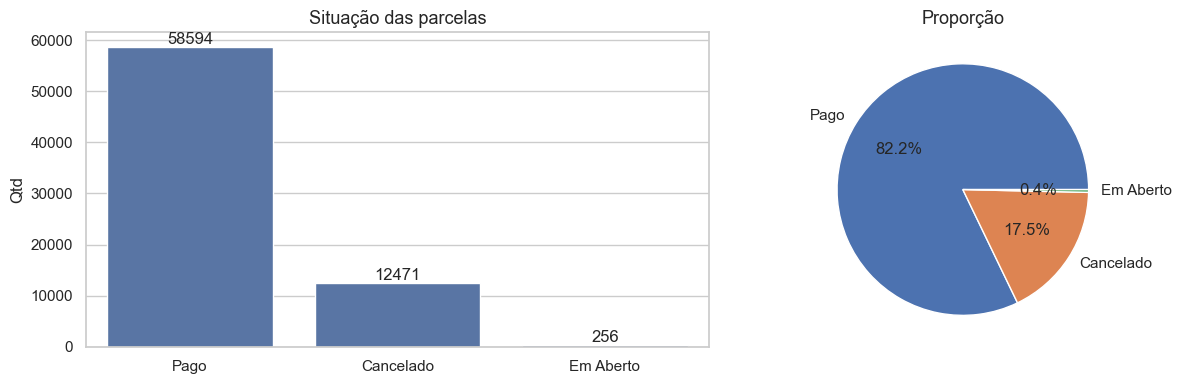

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ordem = df['situacao'].value_counts().index
sns.countplot(data=df, x='situacao', order=ordem, ax=ax[0])
ax[0].set_title('Situação das parcelas'); ax[0].set_xlabel(''); ax[0].set_ylabel('Qtd')
for p in ax[0].patches:
    ax[0].annotate(int(p.get_height()),
                   (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')
df['situacao'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], ylabel='')
ax[1].set_title('Proporção')
plt.tight_layout(); plt.show()

### 4.3 Distribuição do valor das parcelas

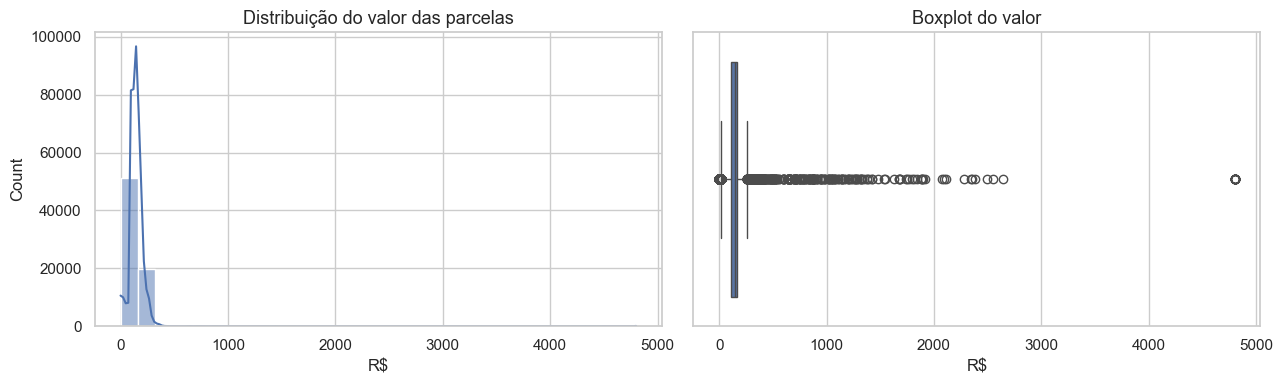

count    71321.00
mean       146.98
std        108.32
min          0.00
25%        109.90
50%        144.90
75%        169.90
max       4800.00
Name: valor, dtype: float64

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['valor'].dropna(), bins=30, kde=True, ax=ax[0])
ax[0].set_title('Distribuição do valor das parcelas'); ax[0].set_xlabel('R$')
sns.boxplot(x=df['valor'].dropna(), ax=ax[1])
ax[1].set_title('Boxplot do valor'); ax[1].set_xlabel('R$')
plt.tight_layout(); plt.show()
df['valor'].describe().round(2)

### 4.4 Modalidades, forma de pagamento e recorrência

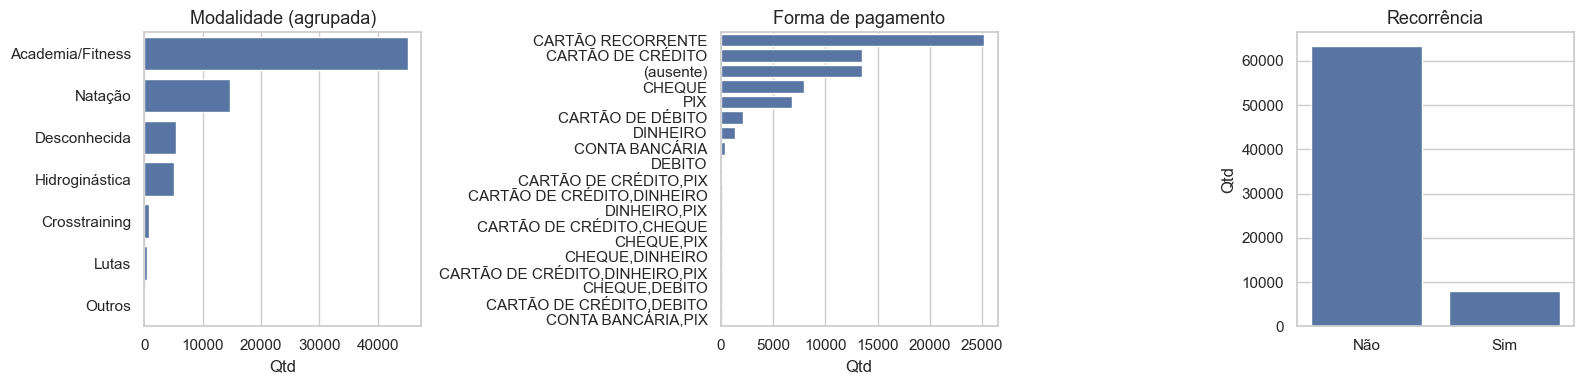

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, y='modalidade_grupo',
              order=df['modalidade_grupo'].value_counts().index, ax=axes[0])
axes[0].set_title('Modalidade (agrupada)'); axes[0].set_xlabel('Qtd'); axes[0].set_ylabel('')

forma = df['forma_pgto'].fillna('(ausente)')
sns.countplot(y=forma, order=forma.value_counts().index, ax=axes[1])
axes[1].set_title('Forma de pagamento'); axes[1].set_xlabel('Qtd'); axes[1].set_ylabel('')

sns.countplot(data=df, x='recorrencia',
              order=df['recorrencia'].value_counts().index, ax=axes[2])
axes[2].set_title('Recorrência'); axes[2].set_xlabel(''); axes[2].set_ylabel('Qtd')
plt.tight_layout(); plt.show()

### 4.5 Volume de parcelas ao longo do tempo

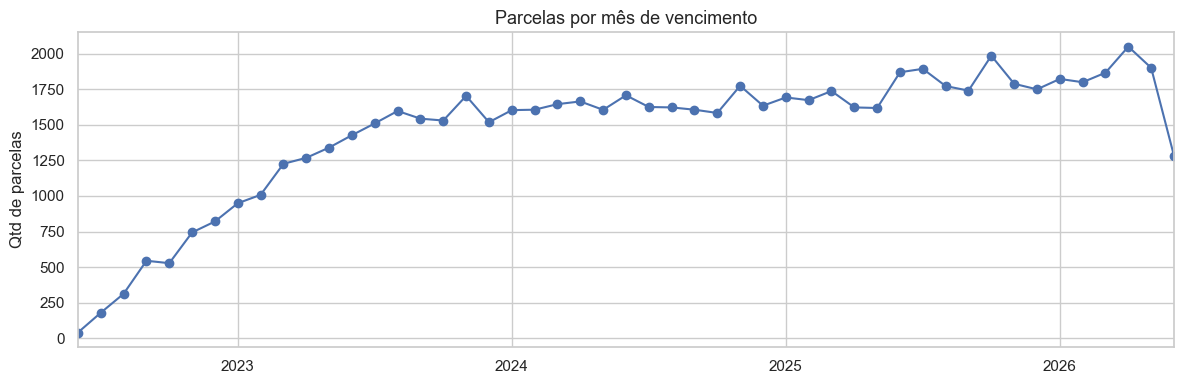

In [9]:
serie = (df.dropna(subset=['vencimento'])
           .set_index('vencimento')
           .resample('ME')
           .size())
plt.figure(figsize=(12, 4))
serie.plot(marker='o')
plt.title('Parcelas por mês de vencimento'); plt.ylabel('Qtd de parcelas'); plt.xlabel('')
plt.tight_layout(); plt.show()

## 5. Engenharia de atributos — base em nível de aluno

Para cada aluno construímos **uma única linha**. Os atributos vêm de **sinais que antecedem o
cancelamento**:

- **Comportamento de pagamento** — calculado apenas sobre as parcelas **pagas**, que por definição
  ocorrem *antes* de o aluno cancelar: atraso médio (dias entre vencimento e pagamento) e % de
  parcelas pagas **em dia**.
- **Perfil estático** (conhecido já na adesão): modalidade, plano, recorrência, forma de pagamento
  predominante, valor médio da parcela, nº de modalidades, nº de telefones e se o responsável pelo
  pagamento é o próprio aluno.

**Decisões para evitar vazamento de dados (*data leakage*):**
- A situação `Cancelado` é a **origem do rótulo** e **nunca** é usada como atributo.
- Não usamos **contagens** de parcelas (nº observadas/pagas): num recorte temporal elas são
  censuradas em pontos diferentes para quem cancelou (no cancelamento) e para quem permaneceu
  (no fim da amostra), virando um *proxy* do rótulo. Usamos apenas **médias e taxas**.
- Alunos sem pagamento registrado ficam com `forma_pgto = 'Desconhecida'` e comportamento imputado
  pela mediana — **sem** criar um indicador de ausência, que também seria proxy do rótulo.

> ⚠️ **Limitação desta amostra.** O recorte cobre apenas as parcelas 8–18. Quando um aluno cancela,
> o sistema marca de uma só vez as parcelas futuras como `Cancelado`; assim, boa parte do histórico
> de pagamento de quem cancelou está **antes** da parcela 8 (fora do arquivo). Por isso as métricas
> aqui são **ilustrativas** e tendem a ser otimistas (não ter pagamento observado já sinaliza churn
> nesta janela). Na **base completa (~70k linhas)**, com histórico integral por aluno, o modelo se
> apoia em sinais comportamentais reais e as estimativas ficam mais confiáveis.

In [10]:
def reduzir_cardinalidade(serie, top, outro='Outros'):
    vals = serie.value_counts().nlargest(top).index
    return serie.where(serie.isin(vals), outro)

def _moda(serie, default=np.nan):
    s = serie.dropna()
    if len(s) == 0:
        return default
    m = s.mode()
    return m.iloc[0] if len(m) else default

def construir_base_aluno(df):
    df = df.sort_values(['matricula', 'parcela_num']).copy()
    linhas = []
    for mat, g in df.groupby('matricula'):
        churn  = int((g['situacao'] == 'Cancelado').any())
        # pagamentos ocorrem necessariamente ANTES do cancelamento -> sinais pre-churn
        pagas  = g[g['situacao'] == 'Pago']
        atraso = (pagas['pagamento'] - pagas['vencimento']).dt.days
        ref    = pagas if len(pagas) else g     # perfil a partir das parcelas pagas, quando houver
        linhas.append({
            'matricula':         mat,
            'churn':             churn,
            # ---- comportamento de pagamento (medias/taxas, sem contagens) ----
            'atraso_medio_dias': atraso.mean() if len(atraso) else np.nan,
            'pct_em_dia':        (atraso <= 0).mean() if len(atraso) else np.nan,
            'valor_medio':       g['valor'].mean(),
            # ---- perfil estatico (conhecido na adesao) ----
            'n_modalidades':     _moda(ref['n_modalidades'], 0),
            'n_telefones':       _moda(ref['n_telefones'], 0),
            'modalidade_grupo':  _moda(ref['modalidade_grupo'], 'Desconhecida'),
            'plano':             _moda(ref['plano'], 'Desconhecido'),
            'recorrencia':       _moda(ref['recorrencia'], 'Não'),
            'forma_pgto':        _moda(pagas['forma_pgto'], 'Desconhecida') if len(pagas) else 'Desconhecida',
            'resp_proprio':      int(str(_moda(g['resp_pgto'], '')).strip().lower()
                                     == str(g['nome'].iloc[0]).strip().lower()),
        })
    base = pd.DataFrame(linhas)
    base['plano']      = reduzir_cardinalidade(base['plano'], TOP_PLANOS)
    base['forma_pgto'] = reduzir_cardinalidade(base['forma_pgto'], TOP_FORMAS)
    return base

base = construir_base_aluno(df)
print('Base nivel aluno:', base.shape)
print('Taxa de churn: {:.1f}%'.format(base['churn'].mean() * 100))
base.head()

Base nivel aluno: (4364, 12)
Taxa de churn: 41.5%


,matricula,churn,atraso_medio_dias,pct_em_dia,valor_medio,n_modalidades,n_telefones,modalidade_grupo,plano,recorrencia,forma_pgto,resp_proprio
0,000001,1,0.000000,1.000000,81.030769,0,1,Desconhecida,Outros,Não,CARTÃO DE CRÉDITO,0
1,000006,1,0.730769,0.666667,119.189286,9,1,Academia/Fitness,"GOLD RECORRENCIA 9,90",Sim,CARTÃO RECORRENTE,0
2,000008,1,2.214286,0.642857,169.520000,1,1,Natação,PLANO NATACAO OU HIDROGINASTICA 3X (RECORRENCIA),Não,PIX,0
3,000009,0,-167.833333,1.000000,176.950000,7,1,Academia/Fitness,PLANO GOLD,Não,CARTÃO DE CRÉDITO,0
4,000018,1,-0.230769,0.846154,206.566667,1,1,Hidroginástica,PLANO NATACAO OU HIDROGINASTICA 3X (RECORRENCIA),Não,CARTÃO DE CRÉDITO,0


## 6. EDA orientada ao alvo

### 6.1 Balanceamento do alvo

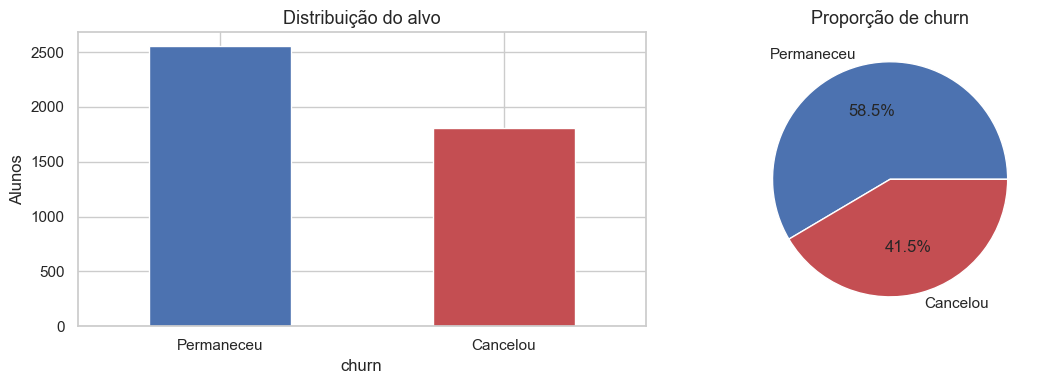

In [11]:
rotulo = base['churn'].map({0: 'Permaneceu', 1: 'Cancelou'})
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
rotulo.value_counts().plot.bar(ax=ax[0], color=['#4c72b0', '#c44e52'])
ax[0].set_title('Distribuição do alvo'); ax[0].set_ylabel('Alunos'); ax[0].tick_params(axis='x', rotation=0)
rotulo.value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], ylabel='', colors=['#4c72b0', '#c44e52'])
ax[1].set_title('Proporção de churn')
plt.tight_layout(); plt.show()

### 6.2 Taxa de churn por categoria

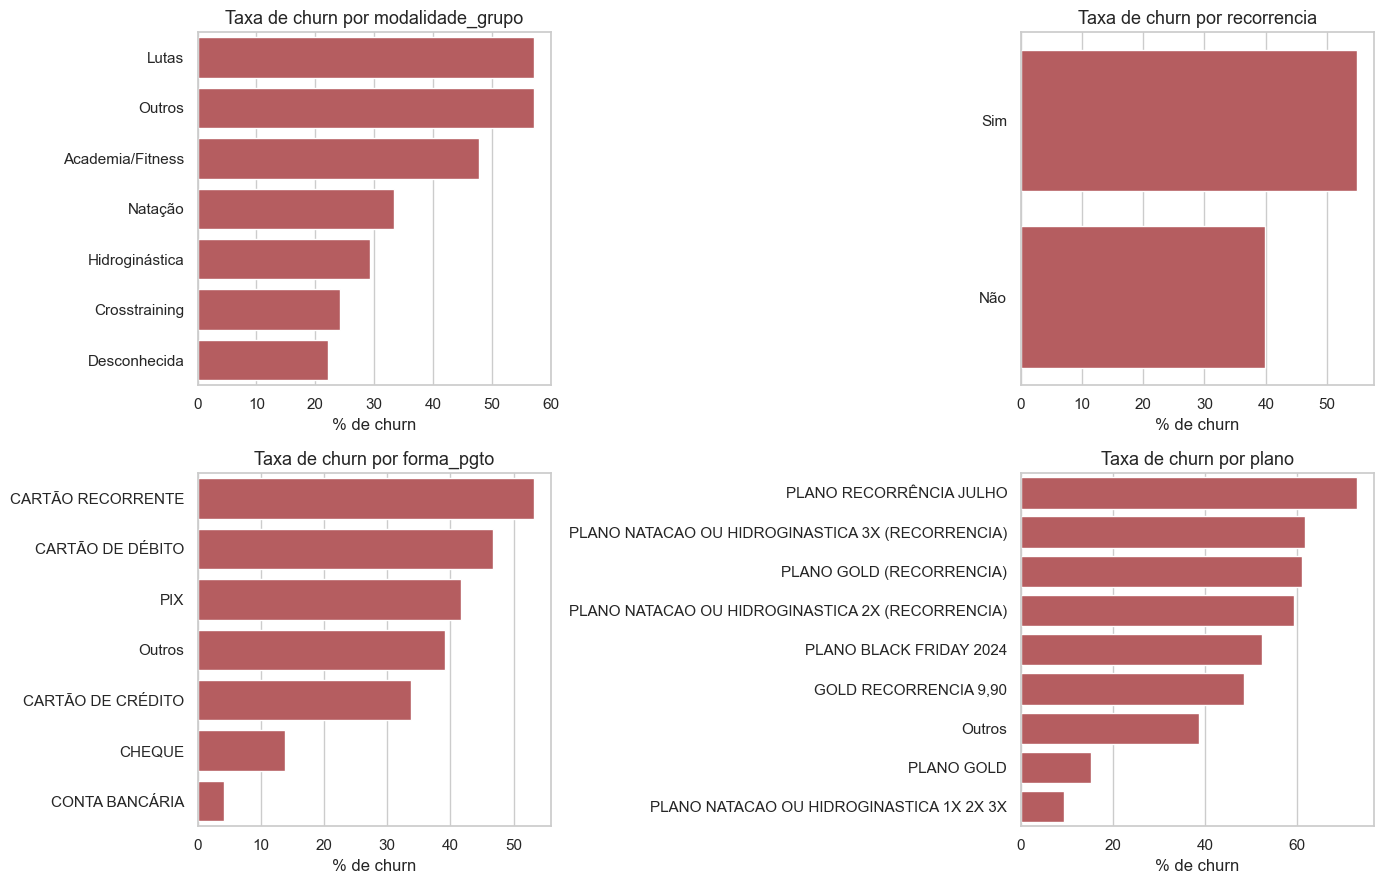

In [12]:
cats = ['modalidade_grupo', 'recorrencia', 'forma_pgto', 'plano']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, c in zip(axes.ravel(), cats):
    taxa = base.groupby(c)['churn'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=taxa.values, y=taxa.index.astype(str), ax=ax, color='#c44e52')
    ax.set_title('Taxa de churn por ' + c); ax.set_xlabel('% de churn'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### 6.3 Atributos numéricos vs. churn

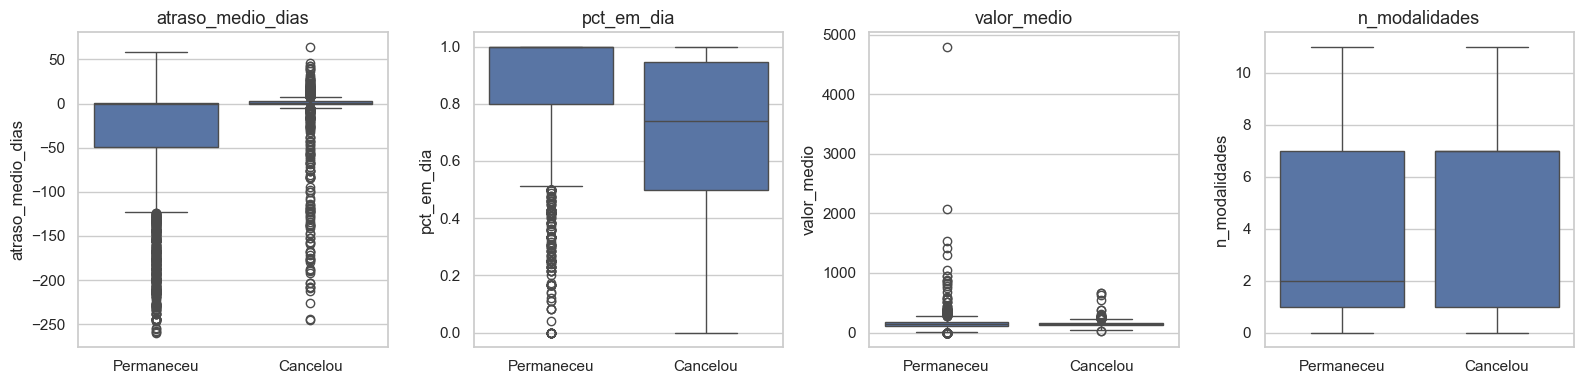

In [13]:
nums = ['atraso_medio_dias', 'pct_em_dia', 'valor_medio', 'n_modalidades']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, nums):
    sns.boxplot(data=base, x='churn', y=c, ax=ax)
    ax.set_title(c); ax.set_xlabel(''); ax.set_xticklabels(['Permaneceu', 'Cancelou'])
plt.tight_layout(); plt.show()

### 6.4 Correlação entre atributos numéricos

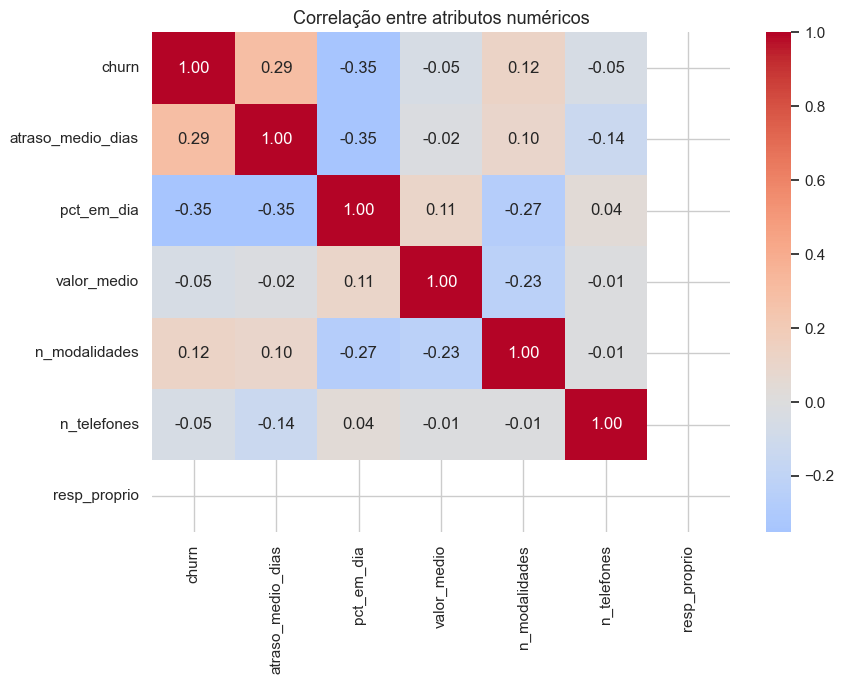

In [14]:
num_cols = base.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(9, 7))
sns.heatmap(base[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre atributos numéricos')
plt.tight_layout(); plt.show()

## 7. Preparação para a modelagem

- Separação **treino/teste** estratificada (mantém a proporção de churn).
- **Pré-processamento** com `ColumnTransformer`: imputação + padronização nos numéricos e
  *one-hot encoding* nos categóricos.
- Tudo encapsulado em `Pipeline`, evitando vazamento entre treino e teste.

In [15]:
ALVO = 'churn'
features  = [c for c in base.columns if c not in ['matricula', ALVO]]
num_feats = base[features].select_dtypes(include=[np.number]).columns.tolist()
cat_feats = [c for c in features if c not in num_feats]
print('Numericos :', num_feats)
print('Categoricos:', cat_feats)

X = base[features]
y = base[ALVO]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print('Treino:', X_tr.shape, '| Teste:', X_te.shape)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_feats),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  ohe)]), cat_feats),
])

Numericos : ['atraso_medio_dias', 'pct_em_dia', 'valor_medio', 'n_modalidades', 'n_telefones', 'resp_proprio']
Categoricos: ['modalidade_grupo', 'plano', 'recorrencia', 'forma_pgto']
Treino: (3273, 10) | Teste: (1091, 10)


## 8. Treinamento e comparação de modelos

Comparamos cinco algoritmos. O desbalanceamento de classes é tratado com
`class_weight='balanced'` (ou `scale_pos_weight` no XGBoost), **sem** necessidade de
bibliotecas extras de *oversampling*.

In [16]:
n_pos = int(y_tr.sum()); n_neg = int(len(y_tr) - n_pos)
spw   = n_neg / max(n_pos, 1)

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'Árvore de Decisão':   DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                                                  random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                  random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
}
if TEM_XGB:
    modelos['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                       subsample=0.9, colsample_bytree=0.9,
                                       scale_pos_weight=spw, eval_metric='logloss',
                                       random_state=RANDOM_STATE)

ajustados, proba_te, pred_te, resultados = {}, {}, {}, []
for nome, est in modelos.items():
    pipe = Pipeline([('prep', pre), ('clf', est)])
    pipe.fit(X_tr, y_tr)
    p  = pipe.predict_proba(X_te)[:, 1]
    yp = pipe.predict(X_te)
    ajustados[nome] = pipe; proba_te[nome] = p; pred_te[nome] = yp
    resultados.append({
        'Modelo':   nome,
        'Acurácia': accuracy_score(y_te, yp),
        'Precisão': precision_score(y_te, yp, zero_division=0),
        'Recall':   recall_score(y_te, yp, zero_division=0),
        'F1':       f1_score(y_te, yp, zero_division=0),
        'ROC-AUC':  roc_auc_score(y_te, p),
        'PR-AUC':   average_precision_score(y_te, p),
    })

res_df = pd.DataFrame(resultados).set_index('Modelo').sort_values('ROC-AUC', ascending=False)
res_df.round(3)

,Acurácia,Precisão,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
XGBoost,0.787,0.713,0.817,0.761,0.861,0.808
Random Forest,0.768,0.710,0.746,0.728,0.847,0.764
Gradient Boosting,0.758,0.701,0.726,0.714,0.838,0.759
Árvore de Decisão,0.727,0.662,0.698,0.680,0.787,0.652
Regressão Logística,0.703,0.613,0.775,0.684,0.772,0.669


### 8.1 Validação cruzada (estabilidade das métricas)

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {}
for nome, est in modelos.items():
    pipe = Pipeline([('prep', pre), ('clf', est)])
    cv_scores[nome] = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc')
    print('{:22s} ROC-AUC CV: {:.3f} +/- {:.3f}'.format(
        nome, cv_scores[nome].mean(), cv_scores[nome].std()))

Regressão Logística    ROC-AUC CV: 0.773 +/- 0.012
Árvore de Decisão      ROC-AUC CV: 0.791 +/- 0.012


Random Forest          ROC-AUC CV: 0.849 +/- 0.011


Gradient Boosting      ROC-AUC CV: 0.840 +/- 0.012


XGBoost                ROC-AUC CV: 0.852 +/- 0.011


## 9. Gráficos de desempenho e comparação

### 9.1 Comparação de métricas

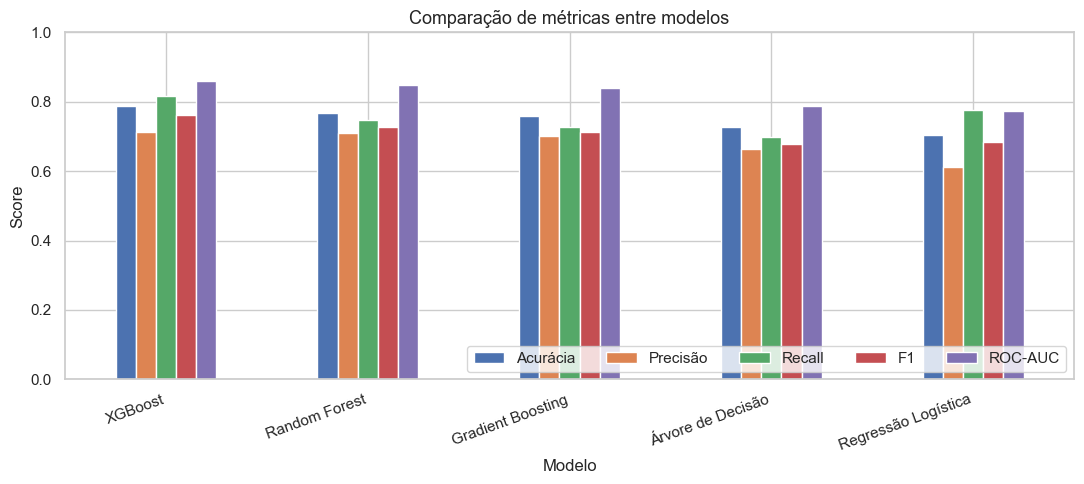

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
res_df[['Acurácia', 'Precisão', 'Recall', 'F1', 'ROC-AUC']].plot.bar(ax=ax)
ax.set_title('Comparação de métricas entre modelos'); ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.legend(loc='lower right', ncol=5)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

### 9.2 Curvas ROC e Precisão-Recall

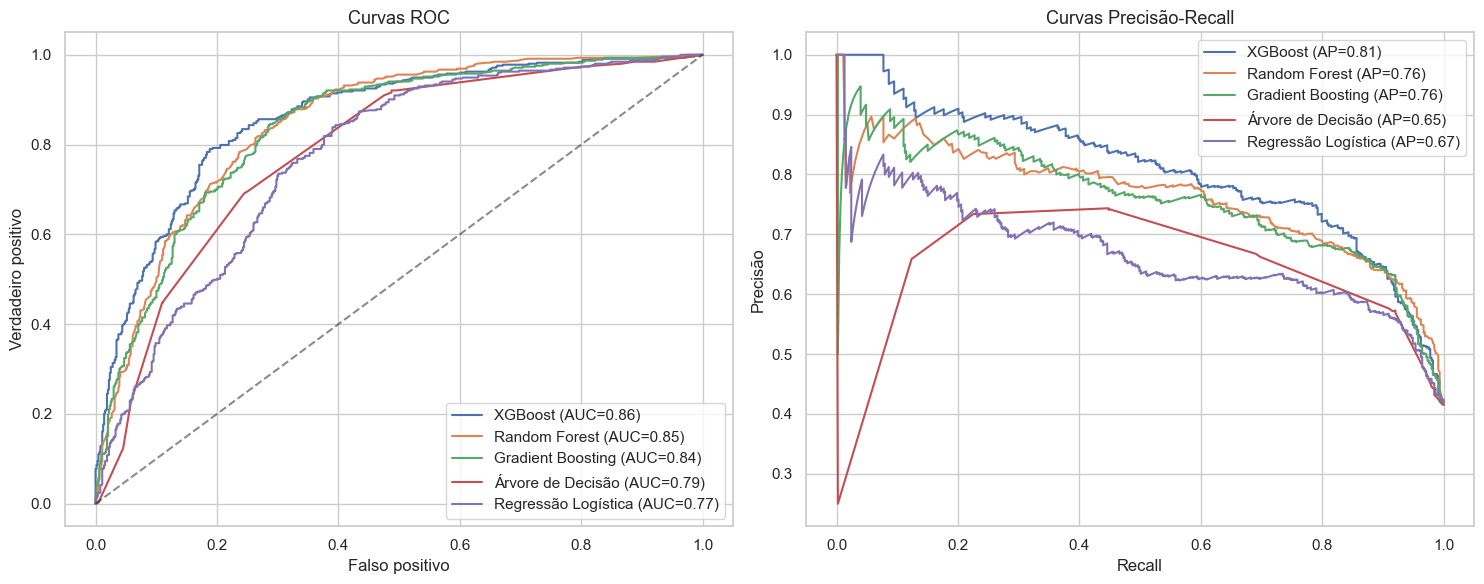

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for nome in res_df.index:
    fpr, tpr, _ = roc_curve(y_te, proba_te[nome])
    ax[0].plot(fpr, tpr, label='{} (AUC={:.2f})'.format(nome, roc_auc_score(y_te, proba_te[nome])))
ax[0].plot([0, 1], [0, 1], 'k--', alpha=.5)
ax[0].set_xlabel('Falso positivo'); ax[0].set_ylabel('Verdadeiro positivo')
ax[0].set_title('Curvas ROC'); ax[0].legend()

for nome in res_df.index:
    prec, rec, _ = precision_recall_curve(y_te, proba_te[nome])
    ax[1].plot(rec, prec, label='{} (AP={:.2f})'.format(nome, average_precision_score(y_te, proba_te[nome])))
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precisão')
ax[1].set_title('Curvas Precisão-Recall'); ax[1].legend()
plt.tight_layout(); plt.show()

### 9.3 Estabilidade na validação cruzada

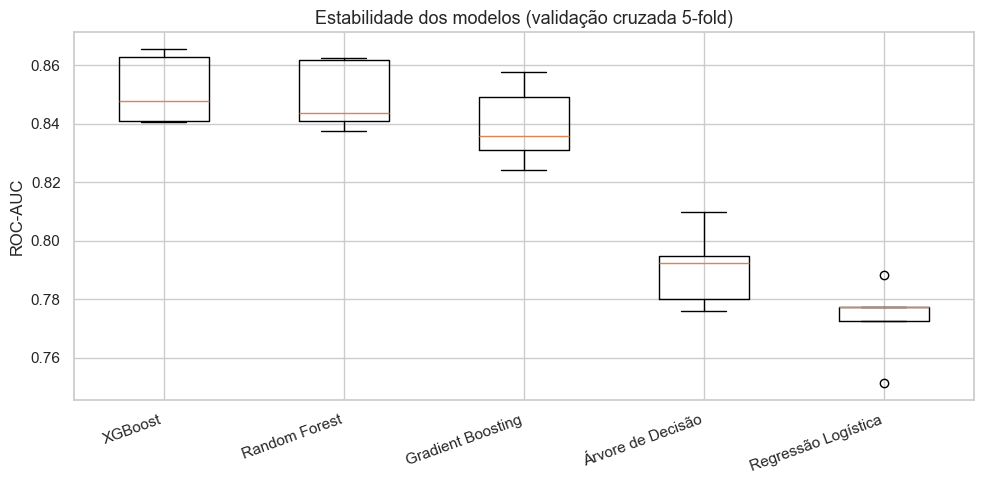

In [20]:
plt.figure(figsize=(10, 5))
plt.boxplot([cv_scores[n] for n in res_df.index])
plt.xticks(range(1, len(res_df) + 1), list(res_df.index), rotation=20, ha='right')
plt.ylabel('ROC-AUC'); plt.title('Estabilidade dos modelos (validação cruzada 5-fold)')
plt.tight_layout(); plt.show()

### 9.4 Matrizes de confusão

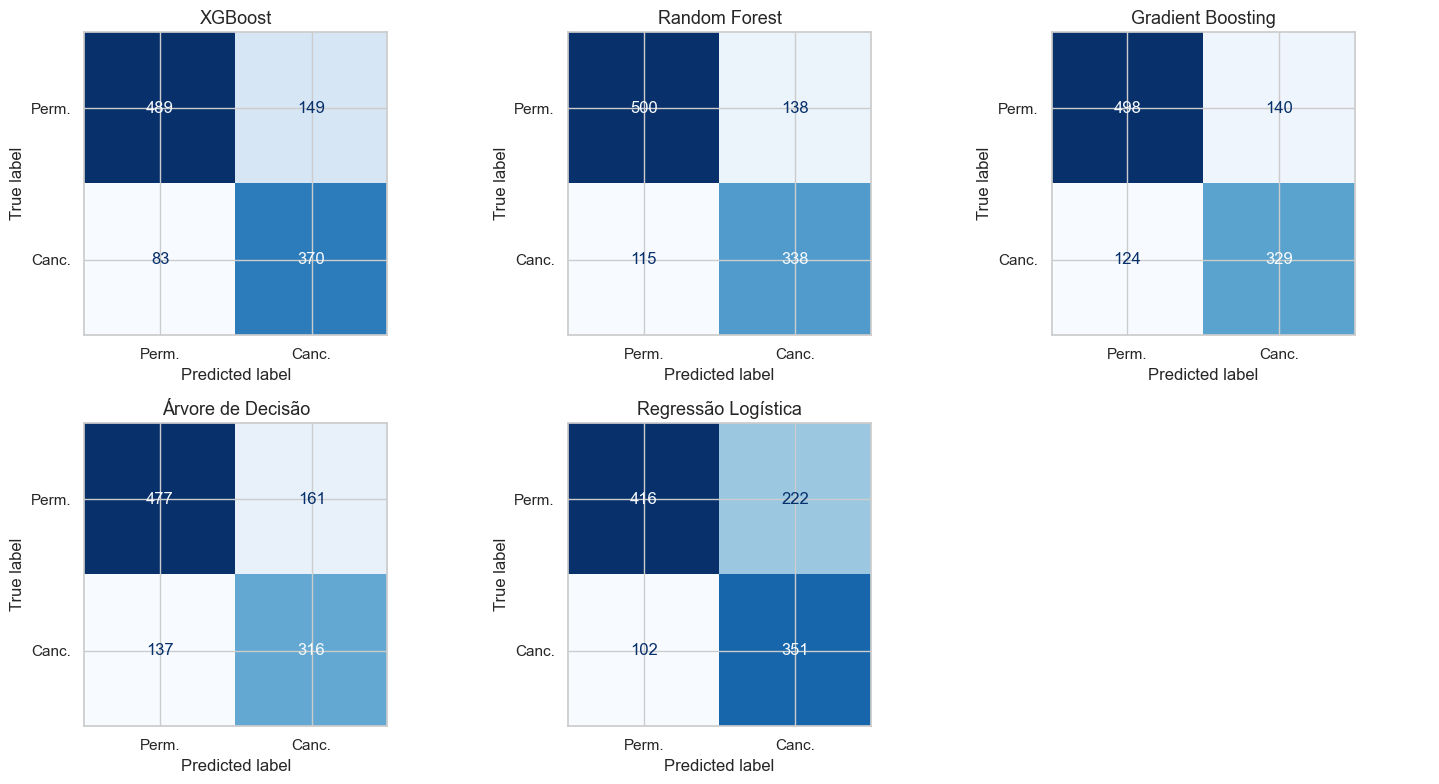

In [21]:
n = len(ajustados); cols = 3; rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).ravel()
for ax, nome in zip(axes, res_df.index):
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred_te[nome]),
                           display_labels=['Perm.', 'Canc.']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 10. Estatísticas do melhor modelo

Relatório de classificação detalhado (precisão, recall, F1 por classe) do modelo com maior
ROC-AUC no conjunto de teste.

In [22]:
melhor = res_df.index[0]
print('Melhor modelo por ROC-AUC:', melhor, '\n')
print(classification_report(y_te, pred_te[melhor], target_names=['Permaneceu', 'Cancelou']))

Melhor modelo por ROC-AUC: XGBoost 

              precision    recall  f1-score   support

  Permaneceu       0.85      0.77      0.81       638
    Cancelou       0.71      0.82      0.76       453

    accuracy                           0.79      1091
   macro avg       0.78      0.79      0.78      1091
weighted avg       0.80      0.79      0.79      1091



## 11. Interpretabilidade

### 11.1 Importância dos atributos (modelo vencedor)

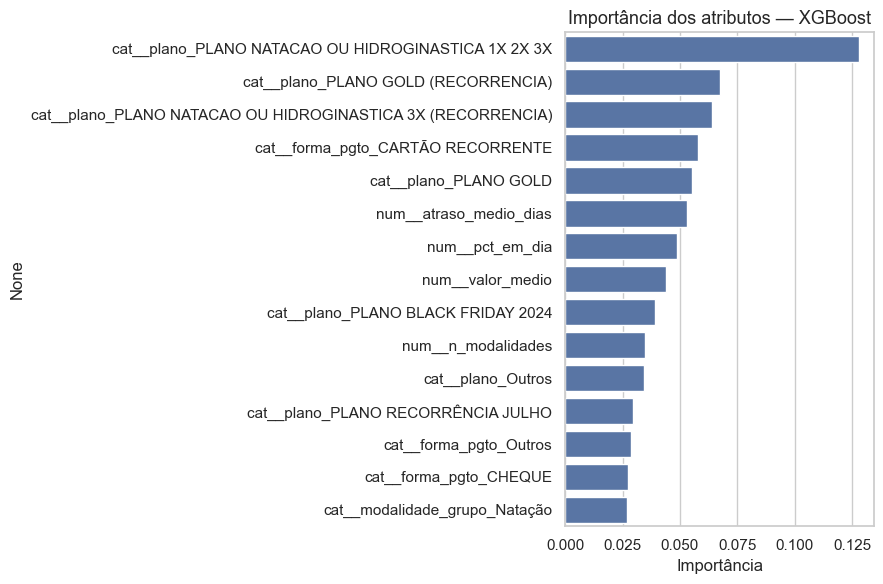

In [23]:
melhor_pipe = ajustados[melhor]
nomes_feat  = melhor_pipe.named_steps['prep'].get_feature_names_out()
clf         = melhor_pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=nomes_feat).sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=imp.values, y=imp.index, color='#4c72b0')
    plt.title('Importância dos atributos — ' + melhor); plt.xlabel('Importância')
    plt.tight_layout(); plt.show()
else:
    print('O modelo vencedor nao expoe feature_importances_; ver importancia por permutacao abaixo.')

### 11.2 Importância por permutação (model-agnostic)

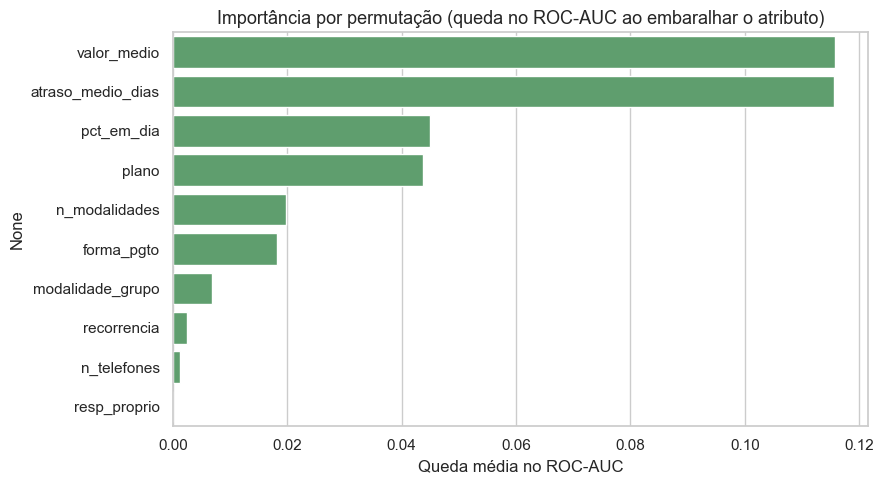

In [24]:
perm = permutation_importance(melhor_pipe, X_te, y_te, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='roc_auc')
imp_perm = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False).head(12)
plt.figure(figsize=(9, 5))
sns.barplot(x=imp_perm.values, y=imp_perm.index, color='#55a868')
plt.title('Importância por permutação (queda no ROC-AUC ao embaralhar o atributo)')
plt.xlabel('Queda média no ROC-AUC')
plt.tight_layout(); plt.show()

### 11.3 Coeficientes da Regressão Logística (razão de chances)

In [25]:
logpipe = ajustados['Regressão Logística']
nomes   = logpipe.named_steps['prep'].get_feature_names_out()
coefs   = logpipe.named_steps['clf'].coef_[0]
odds = pd.DataFrame({'atributo': nomes, 'coef': coefs, 'razao_chances': np.exp(coefs)})
odds = odds.reindex(odds['coef'].abs().sort_values(ascending=False).index).head(15)
print('razao_chances > 1 => aumenta a chance de churn; < 1 => reduz')
odds.round(3).reset_index(drop=True)

razao_chances > 1 => aumenta a chance de churn; < 1 => reduz


,atributo,coef,razao_chances
0,cat__forma_pgto_CONTA BANCÁRIA,-1.722,0.179
1,cat__plano_PLANO NATACAO OU HIDROGINASTICA 1X ...,-1.492,0.225
2,cat__plano_PLANO GOLD,-0.892,0.410
3,cat__plano_PLANO NATACAO OU HIDROGINASTICA 3X ...,0.839,2.314
4,cat__modalidade_grupo_Lutas,0.802,2.229
5,cat__forma_pgto_CHEQUE,0.774,2.168
6,cat__plano_PLANO GOLD (RECORRENCIA),0.742,2.100
7,cat__modalidade_grupo_Desconhecida,-0.729,0.483
8,cat__plano_PLANO RECORRÊNCIA JULHO,0.630,1.878
9,cat__forma_pgto_Outros,0.630,1.877
